# Facebook Artist Page Network (2017)

This notebook includes a comprehensive analysis of a Facebook artist pages network, sourced from the Network Data Repository (Rossi & Ahmed, 2015). The dataset was originally introduced by Rozemberczki et al. (2019) and consists of 819,096 connections between 50,492 nodes. It is represented as an edge list where each row is a mutual like between two artists. This setup provides a structured view of the global music industry on Facebook, potentially revealing community formations, an artist's influence within clusters, and more. The notebook attempts to identify and reveal such structures by applying a series of graph analytics functions from the igraph package in R, accompanied by visual representations of the extracted data.

List of igraph functions used in this notebook:

### R Functions used in the notebook

- `read.csv()`
- `as.character()`
- `cat()`
- `print()`
- `head()`
- `data.frame()`
- `order()`
- `sort()`
- `names()`
- `length()`
- `mean()`
- `round()`
- `unique()`
- `format()`
- `lapply()`
- `do.call()`
- `seq_along()`
- `subset()`
- `nrow()`
- `graph_from_data_frame()`
- `vcount()`
- `ecount()`
- `edge_density()`
- `degree()`
- `assortativity_degree()`
- `mean_distance()`
- `constraint()`
- `edge_connectivity()`
- `bridges()`
- `ends()`
- `vertex_connectivity()`
- `articulation_points()`
- `betweenness()`
- `transitivity()`
- `coreness()`
- `page_rank()`
- `diameter()`
- `get_diameter()`
- `largest_cliques()`
- `ego()`
- `induced_subgraph()`
- `power_centrality()`
- `cluster_louvain()`
- `membership()`
- `sizes()`
- `layout_with_fr()`
- `plot()`
- `V()`

# 1. Loading data
The dataset is loaded from two files - an edge list and a node list. The node identifiers are aligned with the edge list using the `new_id` column, and 23 edges referencing unlisted nodes are removed to ensure consistency. The graph is then constructed as an undirected network using igraph's `graph_from_data_frame()`, with artist names attached as node labels.

In [1]:
# Reading the graph from the file into an edge list
edges <- read.csv("./data/fb-pages-artist.edges", header = FALSE, col.names = c("from", "to"))
nodes <- read.csv("./data/fb-pages-artist.nodes", header = TRUE)

nodes$new_id <- as.character(nodes$new_id)
edges$from <- as.character(edges$from)
edges$to <- as.character(edges$to)

# Removing edges where either endpoint is missing from nodes
valid_ids <- nodes$new_id
edges <- edges[edges$from %in% valid_ids & edges$to %in% valid_ids,]



# 2. Importing the igraph package

In [2]:
library("igraph")


Attaching package: 'igraph'


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union




### Graph properties

In [3]:
# Creating the graph from the edge list
g <- graph_from_data_frame(edges, directed = FALSE, vertices = nodes[, c("new_id", "name")])

cat("Vertices:", vcount(g), "\n")
cat("Edges:", ecount(g), "\n")
cat("Density:", format(edge_density(g), scientific = FALSE), "\n")
cat("Maximum degree:", max(degree(g)), "\n")
cat("Average degree:", round(mean(degree(g)), 2), "\n")
cat("Minimum degree:", min(degree(g)), "\n")

Vertices: 50492 
Edges: 819096 
Density: 0.0006425816 
Maximum degree: 1468 
Average degree: 32.44 
Minimum degree: 1 


# 3. Graph Simplification
The dataset consists of undirected edges without duplicates or self-loops. To properly analyze the overall network, **Sections 4 and 5** apply all functions to the cleaned data. The graph was simplified in the following cases: **(e) Power Centrality** and the final community visualization in **(f) Community Detection**. The full network was too large to visualize clearly or compute efficiently, so a smaller subgraph was created by selecting the nodes with the highest degree (i.e., the most connected artists). This preserves the most structurally important part of the network while making visualization and computation feasible. For visualization purposes, the dataset is further reduced to around 100 vertices in **Section 6**, which discusses the methods used to achieve this size.

# 4. igraph functions
In this section various graph analysis functions from the igraph package are applied on the network.

The assortativity coefficient in this context measures the tendency of artists to connect with similar ones, whether in terms of popularity, genre, or other attributes. The coefficient ranges from -1 to 1, where positive values indicate that artists tend to connect with similar artists, negative values indicate the opposite, and values near zero suggest no clear pattern. In this network, the coefficient is -0.019, which is very close to zero, indicating that connections form with no strong preference for any particlar kind of pages. This suggests that mutual likes between artist pages are largely independent of popularity or connectivity, reflecting a relatively random distribution pattern in the network.

In [4]:
g.assort <- assortativity_degree(g)
cat("Assortativity:", g.assort, "\n")

Assortativity: -0.01899474 


The average path length reveals how closely connected the artists in the network are. A value of 3.67 suggests that, on average, it takes 3 to 4 steps to find a path between any two artists in the network.

In [5]:
cat("Average path length:", mean_distance(g), "\n")

Average path length: 3.68617 


The constraint value measures how redundant the connections of a given artist are. A highly constrained node is part of a tightly connected cluster where the majority of its neighbors are also mutually connected, limiting its reach in the broader network. 
A lower constraint value, on the other hand, suggests a more powerful set of connections, indicating that a given node can reach far more distant, disconnected segments of the network. 

In [6]:
g.constraint <- constraint(g)

node_names <- V(g)$name
# mapping node names and constraint values
const_df <- data.frame(name = node_names, constraint = g.constraint)

# asc order
const_df <- const_df[order(const_df$constraint, na.last = TRUE), ]

cat("Top 10 least constrained:\n")
print(head(const_df, 10), row.names = FALSE)

Top 10 least constrained:
            name   constraint
           Adele 0.0009166923
       Lady Gaga 0.0009251561
         Beyoncé 0.0009272920
    Taylor Swift 0.0009278637
 Michael Jackson 0.0009295877
       Radiohead 0.0009338074
         Rihanna 0.0009401778
     The Beatles 0.0009735866
      Katy Perry 0.0010636533
     Yuna Alvara 0.0010659838


Edge connectivity value shows how the minimum number of edges it would take to remove from network in order to disconnect it. 

In [ ]:
g.ec <- edge_connectivity(g)
cat("Edge connectivity:", g.ec, "\n")

g.bridges <- bridges(g)
cat("Number of bridge edges:", length(g.bridges), "\n")

Edge connectivity: 1 
Number of bridge edges: 3215 


Similarly, vertex connectivity value shows how the minimum number of vertices it would take to remove from network in order to disconnect it.

In [ ]:
g.vc <- vertex_connectivity(g)
cat("Vertex connectivity:", g.vc, "\n")

# get all articulation points
g.ap <- articulation_points(g)

cat("Number of articulation points:", length(g.ap), "\n")

Vertex connectivity: 1 
Articulation points:
   [1] "BAXTER"                                                     
   [2] "David DiMuzio"                                              
   [3] "Amy Nadine Beauty"                                          
   [4] "Gayatri Asokan"                                             
   [5] "Jimmy Ingrassia"                                            
   [6] "Rashmika Mandanna"                                          
   [7] "Trapp Tha General"                                          
   [8] "Zach Nelson"                                                
   [9] "AfricanGroove"                                              
  [10] "D8"                                                         
  [11] "Martin Maro"                                                
  [12] "劉致妤 Shadow Liu"                                          
  [13] "Bob Daisley"                                                
  [14] "Michael Learns To Rock"                              

The betweenness centrality value shows the total number of shortest paths that pass through a given node. In this dataset, the highest value belongs to the page "Yuna Alvara", exceeding 34 million, which is approximately 8 million more than the second highest result, highlighting its role as a connector in the network.

In [9]:
g.betweenness <- betweenness(g)

# mapping node names to betweenness values
bet_df <- data.frame(name = node_names, betweenness = g.betweenness)

# desc order
bet_df <- bet_df[order(bet_df$betweenness, decreasing = TRUE), ]

cat("Top 10 by betweenness centrality:\n")
print(head(bet_df, 10), row.names = FALSE)
cat("Average betweenness:", mean(g.betweenness), "\n")

# save values in a dataframe
betweenness_df <- data.frame(
  name = V(g)$name,
  betweenness = g.betweenness
)

Top 10 by betweenness centrality:
            name betweenness
     Yuna Alvara    34339973
        PLASTIKO    27966419
    Taylor Swift    21329707
         Beyoncé    19750717
   Justin Bieber    19483837
           Adele    18600586
 Michael Jackson    17597967
       Lady Gaga    17201011
       Radiohead    16722382
      Eddy Ciuno    16329629
Average betweenness: 67813.69 


Transitivity metric shows the probability that there exists a connection between two neighbors of a given node. The value of 0.05 suggests that, generally, the network doesn't have many tightly connected groups of pages.

In [10]:
g.transitivity <- transitivity(g)
cat("Transitivity:", g.transitivity, "\n")

Transitivity: 0.05350679 


Coreness value is the number of connections each node has in the most connected portion of the network a given node belongs to. In other words, it shows the most tightly connected and mutually recognized groups of artists. From the list below it can be seen that the nodes with highest coreness paratemter are mostly the relatively smaller artist pages sharing mutual likes between each other, since their betweenness values are also quite small. The table below groups artist pages by their coreness level, showing the number of pages at each level and their average betweenness centrality. As can be seen, all top coreness levels show average betweenness values that are significantly higher than the overall network average of 67,813, indicating that the most densely interconnected artist pages are also important bridges in the network overall. 

In [11]:
coreness_df <- data.frame(
  name = V(g)$name,
  coreness = coreness(g),
  betweenness = g.betweenness
)

# getting 10 highest unique coreness values
top10_coreness <- head(unique(sort(coreness_df$coreness, decreasing = TRUE)), 10)

# top 10 coreness values with average betweenness of nodes in the cluster
top10_summary <- do.call(rbind, lapply(top10_coreness, function(c_val) {
  subset_df <- coreness_df[coreness_df$coreness == c_val, ]
  data.frame(
    coreness       = c_val,
    node_count     = nrow(subset_df),
    avg_betweenness = round(mean(subset_df$betweenness), 4)
  )
}))

print(top10_summary, row.names = FALSE)

 coreness node_count avg_betweenness
       69        533        599363.6
       68        112        206759.1
       67         95        153810.4
       66        126        298833.1
       65         70        954430.6
       64         78       1249523.1
       63         69        700829.3
       62         27        577845.1
       61        444       1343440.4
       60         74        718234.1


PageRank measures the importance of an artist page based on the significance of the pages it is connected to. A high value indicates that an artist is connected to other important pages, making it more prestigious on comparison to lower ranked nodes.

In [12]:
g.pr <- page_rank(g)

# mapping node names with PageRank scores
pagerank_df <- data.frame(
  name = V(g)$name,
  pagerank = g.pr$vector
)

# desc order
pagerank_df <- pagerank_df[order(pagerank_df$pagerank, decreasing = TRUE), ]

cat("Top 10 nodes by PageRank:\n")
print(head(pagerank_df, 10), row.names = FALSE)

Top 10 nodes by PageRank:
            name     pagerank
     Yuna Alvara 0.0008381484
         Beyoncé 0.0008175416
    Taylor Swift 0.0008116855
   Justin Bieber 0.0007731675
        PLASTIKO 0.0007292303
     The Beatles 0.0007095743
           Adele 0.0006860179
         Rihanna 0.0006724327
       Lady Gaga 0.0006692978
 Michael Jackson 0.0006675747


# 5. Graph Analytics
The goal is to identify important nodes, structural patterns, and communities within the graph using igraph and related graph analysis techniques.

### (a) Central Nodes
**Degree centrality** measures how many connections each node has.
Nodes with high degree values are considered central nodes, because they connect to many other nodes in the network.
In this dataset, such nodes may represent **highly influential or widely connected artist pages** within the Facebook network.

In [13]:
# Compute degree centrality using igraph
centrality <- degree(g)

# Get top 10 nodes
top_nodes <- sort(centrality, decreasing = TRUE)[1:10]

# Convert to a clean table
top_nodes_df <- data.frame(
  Artist = names(top_nodes),
  Degree = as.numeric(top_nodes)
)

top_nodes_df

Artist,Degree
<chr>,<dbl>
Taylor Swift,1468
Beyoncé,1461
Yuna Alvara,1352
Justin Bieber,1328
The Beatles,1297
Adele,1241
Rihanna,1230
Lady Gaga,1229
Michael Jackson,1211


The output shows the 10 artist pages with the highest number of connections in the network.
These nodes act as ***hubs***, linking many other artists.

### (b) Longest Path
The **diameter** of a graph represents the longest shortest path between any two nodes in the network.
It provides insight into the **maximum distance between artists** within the network, or in other words, ***the largest number of steps required to travel between two artists***.

In [14]:
# Calculate the diameter of the network
g.diam <- diameter(g)

g.diam

[1] 11

In [15]:
# Retrieve the vertices that form the longest path
longest_path <- get_diameter(g)

longest_path

+ 12/50492 vertices, named, from 86d0631:
 [1] Giuseppe Riggio        Patrick Keil           Sandro Brehorst       
 [4] Ois Easy               LINDA HESSE            Die jungen Zillertaler
 [7] Mark Knopfler          Neil Young             Michael Falch         
[10] Lars Lilholt Band      Johnny Madsen          Allan Olsen           

The notation ***+ 6/8441 vertices*** indicates that the path contains **6 nodes out of the total 8441 nodes** in the graph. The path starts with ONNO and ends with Times Music South, passing through several intermediate artists such as  IVAN MASA, Nicky Romer, Drops,Shruti Haasan. Since this path contains 6 nodes, the number of edges between them is 5, which corresponds to the previously computed ***graph diameter of 5***. This means that these two artists are among the most distant nodes in the network

### (c) Largest Clique
A **clique** is a group of nodes where every node is connected to every other node.
Large cliques indicate tightly connected groups of artists who interact frequently.

The result represents ***a fully connected group of artist pages***, where each artist is directly connected to every other artist in the group.

In [16]:
# Identify the largest fully connected groups in the network
largest_cliques_list <- largest_cliques(g)

# Show the size of the largest clique
length(largest_cliques_list[[1]])

# Display the first largest clique
largest_cliques_list[[1]]

[1] 18

+ 18/50492 vertices, named, from 86d0631:
 [1] Tablo                YG FAMILY            BIGBANG             
 [4] Seungri              G-DRAGON             WINNER              
 [7] 2NE1                 Ava Max              SECHSKIES           
[10] iKON                 Koo Hye Sun - 구혜선 EPIK HIGH           
[13] KANG SEUNG YOON      LEE HI (이하이)      BLACKPINK           
[16] PSY                  CL                   AKMU                

The output above shows one of the largest cliques detected in the network, containing ***18 nodes out of 8441***.

### (d) Ego Networks
An **ego network** represents a node and its immediate neighbors.
It helps analyze the **local structure** around a specific artist.

In [17]:
ego_node <- names(top_nodes)[1]
ego_node

[1] "Taylor Swift"

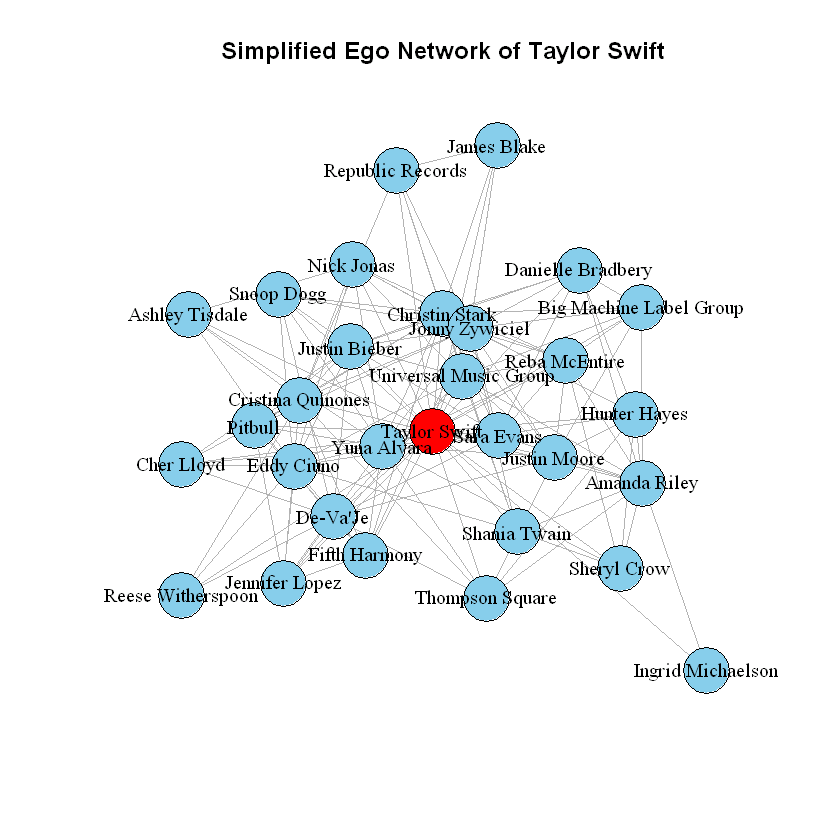

In [18]:
# Get ego nodes
ego_nodes <- ego(g, order = 1, nodes = ego_node)[[1]]

# Create ego subgraph
ego_graph <- induced_subgraph(g, ego_nodes)

# Keep only the top 30 nodes by degree
deg <- degree(ego_graph)
top30 <- names(sort(deg, decreasing = TRUE))[1:30]

ego_graph_small <- induced_subgraph(ego_graph, top30)

# Highlight ego node
V(ego_graph_small)$color <- ifelse(V(ego_graph_small)$name == ego_node, "red", "skyblue")

# Plot the graph
plot(
  ego_graph_small,
  layout = layout_with_fr(ego_graph_small),
  vertex.size = 18,
  vertex.label.cex = 1,
  vertex.label.color = "black",
  edge.color = "gray70",
  main = paste("Simplified Ego Network of", ego_node)
)

The original ego network contained over ***800 nodes (as seen from a Central Nodes section result for this artist)*** due to the high degree of the central node (Calvin Harris). To improve visualization clarity, the network was simplified by keeping only the most connected neighboring nodes, which allowed for a clearer representation of the local network structure while preserving the most significant relationships.

The ego network represents a node and all nodes directly connected to it. In this case, the ego network of the most connected artist shows the local structure surrounding that artist, illustrating how their page is linked to many other artist pages in the network.

### (e) Power Centrality
**Power centrality** measures a node’s influence by considering both **its connections and the importance of its neighbors**.
Nodes connected to other influential nodes will have **higher** power centrality scores.

Power centrality could not be computed on the full graph due to memory limitations. Therefore, it was calculated on a reduced subgraph containing the highest-degree nodes, which preserves the most structurally important part of the network while making the computation feasible.

In [19]:
# Select top 500 nodes by degree
deg <- degree(g)
top500 <- names(sort(deg, decreasing = TRUE))[1:300]

# Create smaller subgraph
g_power <- induced_subgraph(g, top500)

# Compute power centrality on the reduced graph
power_cent <- power_centrality(g_power)

# Top 10 nodes
top_power_nodes <- sort(power_cent, decreasing = TRUE)[1:10]

# Clean table
top_power_df <- data.frame(
  Artist = names(top_power_nodes),
  PowerCentrality = as.numeric(top_power_nodes)
)

top_power_df

Artist,PowerCentrality
<chr>,<dbl>
Dada Life,2.831598
Joris Voorn,1.740981
Miranda Lambert,1.579397
Solomun (Official),1.539153
Nina Kraviz,1.382091
U2,1.346361
Bob Dylan,1.338034
Paul Van Dyk,1.265048
Erykah Badu,1.032097


Artists such as ***Dada Life, Joris Voorn, and Miranda Lambert*** have the highest power centrality scores, suggesting they are connected to other well-connected artists and play an important role in the structure of the network.

Note that, nodes with high power centrality are ***important connectors in the network***, often linking influential artist communities.

### (f) Community Detection
Communities represent groups of nodes that are **more densely connected to each other than to the rest of the network**.

The **Louvain algorithm** is used to detect communities efficiently in large graphs.

The algorithm identifies these groups by maximizing **modularity**, a measure that evaluates how well the network is divided into communities. Higher modularity values indicate stronger community structure. The algorithm works iteratively in two main phases. First, each node is initially placed in its own community. Then, the algorithm repeatedly moves nodes to neighboring communities if doing so increases modularity. Once no node movement can further improve modularity, communities are aggregated into single nodes, forming a smaller network. The process is then repeated on this reduced graph until no further modularity improvement is possible. This hierarchical approach makes our **Louvain algorithm** efficient and particularly suitable for large graphs such as the Facebook artist network analyzed in this notebook.

In [20]:
# Detect communities using the Louvain algorithm
communities <- cluster_louvain(g)

# Number of communities
length(communities)

[1] 35

In [21]:
# Community membership of each node
membership_vec <- membership(communities)

# Convert to a clean table
membership_df <- data.frame(
  Artist = names(membership_vec),
  Community = membership_vec
)

head(membership_df, 10)

,Artist,Community
,<chr>,<dbl>
1,Social Club Misfits,1
2,DAMN DICE,2
3,Evokings,3
4,Comatose Music,2
5,Silent Descent,2
6,Jonwayne,4
7,Joey Massa,5
8,Steel Blossoms,6
9,Voxxclub,7


The table shows the community assignment for each artist detected by the algorithm. Artists with the same community number belong to the same cluster of closely connected nodes in the network.

In [22]:
# Community sizes
community_sizes <- sizes(communities)

community_sizes_df <- data.frame(
  Community = seq_along(community_sizes),
  Size = as.numeric(community_sizes)
)

community_sizes_df

Community,Size
<int>,<dbl>
1,8906
2,4783
3,3866
4,3137
5,3263
6,1794
7,1655
8,10344
9,1309


We can observe the size of each ***detected community***, meaning ***how many artists belong to each cluster*** in the network. Larger communities contain more strongly interconnected artists, while smaller communities represent more specialized or niche groups.

This initial visualization appears dense due to the large number of nodes and edges in the graph. This is a common issue in large-scale networks, where many overlapping edges produced a cluttered structure. Thus, we will take first 30 nodes for better visualization purpose:

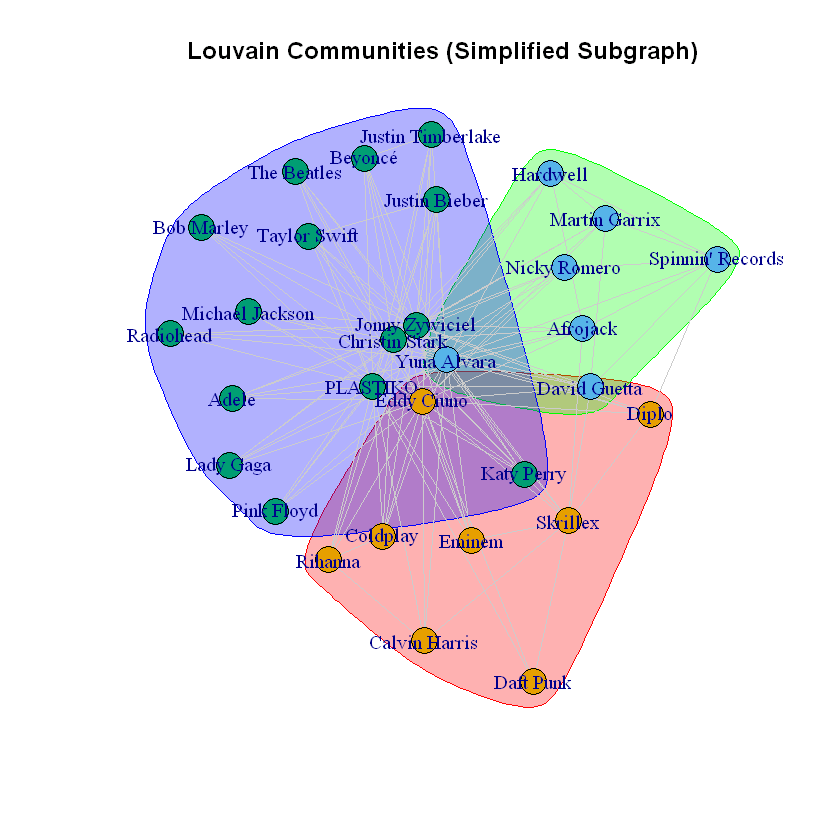

In [23]:
# Take 30 nodes with highest degree for visualization
top_nodes_comm <- names(sort(degree(g), decreasing = TRUE))[1:30]

# Create subgraph
g_vis <- induced_subgraph(g, top_nodes_comm)

# Detect communities
comm_vis <- cluster_louvain(g_vis)

# Plot communities
plot(
  comm_vis,
  g_vis,
  vertex.size = 10,
  vertex.label.cex = 1,
  edge.width = 0.5,
  edge.color = "gray80",
  main = "Louvain Communities (Simplified Subgraph)"
)

The plot visualizes the communities identified by the Louvain algorithm, where each color represents a cluster of closely connected artist pages in the network.

Community detection helps identify ***clusters of artist pages that are closely related***, possibly representing ***shared audiences, genres, or collaborations***.

# 6. Filtering the graph for visualization purposes

*** DESCRPTION HERE ***

*** CODE AND PLOTS HERE ***

## References

Rossi, R. A., & Ahmed, N. K. (2015). The Network Data Repository with Interactive Graph Analytics and Visualization. *AAAI*. http://networkrepository.com

Rozemberczki, B., Allen, C., & Sarkar, R. (2019). Multi-scale attributed node embedding. *arXiv preprint arXiv:1909.13021*. https://arxiv.org/abs/1909.13021